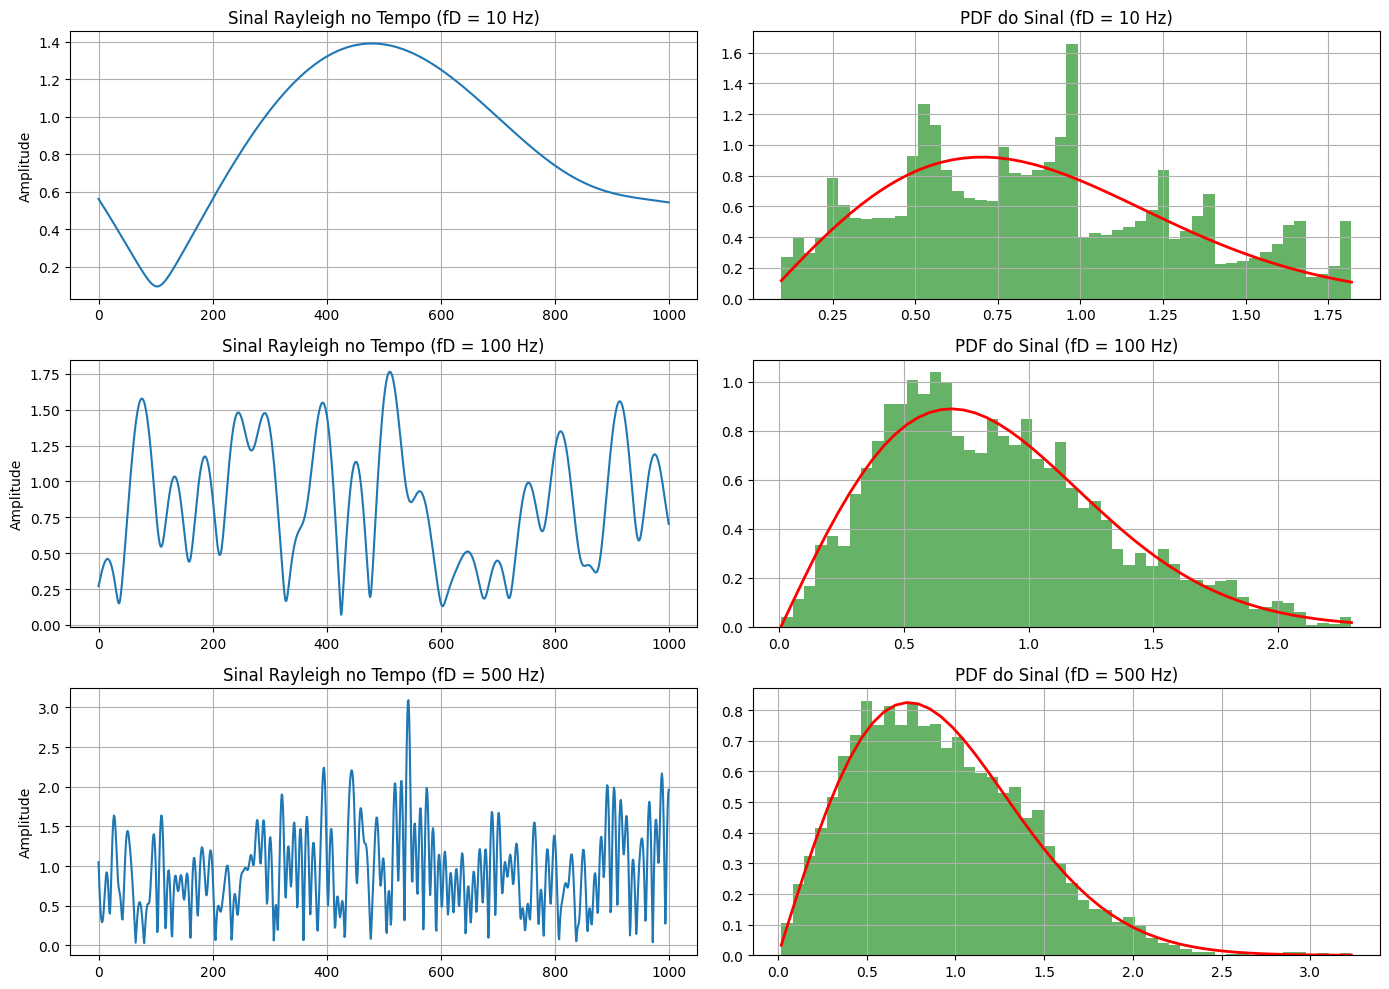

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rayleigh

def generate_rayleigh_fading(K, fd, fs):
    """
    Gera amostras de desvanecimento Rayleigh usando o modelo de Young.
    """
    t = np.arange(K) / fs
    # Gerando componentes In-phase e Quadrature
    # Para simplificar, usamos ruído filtrado ou soma de senoides
    num_sinusoids = 100
    phases = np.random.uniform(0, 2*np.pi, num_sinusoids)
    angles = np.random.uniform(0, 2*np.pi, num_sinusoids)

    # Modelo de Clarke/Gans simplificado
    gain = np.zeros(K, dtype=complex)
    for i in range(num_sinusoids):
        doppler_shift = fd * np.cos(angles[i])
        gain += np.exp(1j * (2 * np.pi * doppler_shift * t + phases[i]))

    gain /= np.sqrt(num_sinusoids)
    return gain

# Parâmetros
fs = 10000  # Frequência de amostragem (10kHz)
K = 5000    # Número de amostras
fd_values = [10, 100, 500] # Diferentes valores de Doppler

plt.figure(figsize=(14, 10))

for i, fd in enumerate(fd_values):
    signal = generate_rayleigh_fading(K, fd, fs)
    magnitude = np.abs(signal)

    # Plot do sinal no tempo
    plt.subplot(len(fd_values), 2, 2*i + 1)
    plt.plot(magnitude[:1000])
    plt.title(f"Sinal Rayleigh no Tempo (fD = {fd} Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True)

    # Plot da PDF
    plt.subplot(len(fd_values), 2, 2*i + 2)
    count, bins, ignored = plt.hist(magnitude, bins=50, density=True, alpha=0.6, color='g')

    # PDF Teórica
    param = rayleigh.fit(magnitude)
    pdf_fitted = rayleigh.pdf(bins, *param)
    plt.plot(bins, pdf_fitted, 'r-', lw=2)
    plt.title(f"PDF do Sinal (fD = {fd} Hz)")
    plt.grid(True)

plt.tight_layout()
plt.show()